In [7]:
import os
import matplotlib.pyplot as plt
import json
import pandas as pd
import seaborn as sns
import numpy as np

In [8]:
class_mapping = {
            0: 'air_conditioner',
            1: 'car_horn',
            2: 'children_playing',
            3: 'dog_bark',
            4: 'drilling',
            5: 'engine_idling',
            6: 'gun_shot',
            7: 'jackhammer',
            8: 'siren',
            9: 'street_music'
        }

dataset_mapping = {
    "singlechannel": "Preprocessing Singlechannel",
    "preprocessing": "Preprocessing Multichannel",
    "augmentation_singlechannel": "Augmentation + Preprocessing Singlechannel",
    "augmentation_preprocessing": "Augmentation + Preprocessing Multichannel"
}

In [9]:
def get_overall_json_file(root_path, model_name, type=None):

    assert type in ["history", "metrics"], "Invalid type specified."

    folder_path = os.path.join(root_path, model_name)
    if os.path.isdir(folder_path):
        if type == "history":
            json_file_path = os.path.join(folder_path, "overall", "all_folds_history.json")
        else:  # type == "metrics"
            json_file_path = os.path.join(folder_path, "overall", "all_folds_metrics.json")
    
    content = json.load(open(json_file_path, "r"))
    return content


In [10]:
def get_models_distributions_dataset(path, dataset_name, type=None, plot=False):

    assert type in ["history", "metrics"], "Invalid type specified."

    dataset_path = os.path.join(path, dataset_name)
    if type == "metrics":
        c = ["model", "accuracy"] + list(class_mapping.values()) + ["precision", "recall", "f1_score", "G_mean"]
        df = pd.DataFrame(columns=c)

    for model_name in os.listdir(dataset_path):
        content = get_overall_json_file(dataset_path, model_name, type=type)

        if type == "metrics":
            for fold in content.keys():
                fold_metrics = content[fold]
                row = {
                    "model": model_name,
                    "accuracy": fold_metrics["accuracy"],
                    "precision": fold_metrics["precision"],
                    "recall": fold_metrics["recall"],
                    "f1_score": fold_metrics["f1_score"],
                    "G_mean": fold_metrics["G_means"]
                }
                for i in range(10):
                    row[class_mapping[i]] = fold_metrics["accuracy_per_class"][i]
                
                df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)

    if plot and type == "metrics":
        plt.figure(figsize=(10, 6))
        df_box = df.melt(id_vars=["model"], value_vars=["accuracy", "precision", "recall", "f1_score", "G_mean"],
                         var_name="Metric", value_name="Value")
        ax = sns.boxplot(x="Metric", y="Value", hue="model", data=df_box)
        ax.set_title(f'Model Comparison on {dataset_mapping[dataset_name]} dataset')
        plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()


In [11]:
def get_models_performance_dataset(path, dataset_name, type=None, plot=False):

    assert type in ["history", "metrics"], "Invalid type specified."

    dataset_path = os.path.join(path, dataset_name)
    if type == "metrics":
        c = ["model", "accuracy"] + list(class_mapping.values()) + ["precision", "recall", "f1_score", "G_mean"]
        df = pd.DataFrame(columns=c)
    

    for model_name in os.listdir(dataset_path):
        content = get_overall_json_file(dataset_path, model_name, type=type)

        if type == "metrics":
            # Initialize accumulators for each metric
            metrics_sum = {
            "accuracy": 0,
            "precision": 0,
            "recall": 0,
            "f1_score": 0,
            "G_mean": 0,
            "accuracy_per_class": [0]*10
            }
            num_folds = len(content.keys())
            for fold in content.keys():
                fold_metrics = content[fold]
                metrics_sum["accuracy"] += fold_metrics["accuracy"]
                metrics_sum["precision"] += fold_metrics["precision"]
                metrics_sum["recall"] += fold_metrics["recall"]
                metrics_sum["f1_score"] += fold_metrics["f1_score"]
                metrics_sum["G_mean"] += fold_metrics["G_means"]
                for i in range(10):
                    metrics_sum["accuracy_per_class"][i] += fold_metrics["accuracy_per_class"][i]
                # Calculate mean for each metric
                row = {
                "model": model_name,
                "accuracy": metrics_sum["accuracy"] / num_folds,
                "precision": metrics_sum["precision"] / num_folds,
                "recall": metrics_sum["recall"] / num_folds,
                "f1_score": metrics_sum["f1_score"] / num_folds,
                "G_mean": metrics_sum["G_mean"] / num_folds
                }
                for i in range(10):
                    row[class_mapping[i]] = metrics_sum["accuracy_per_class"][i] / num_folds
            df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)\
            
        else: # type == "history"
            if plot:
                # Configurar figura com 2x2 subplots
                fig, axes = plt.subplots(2, 2, figsize=(14, 10))
                fig.suptitle(f'Histórico de Treino no modelo {model_name} em {dataset_mapping[dataset_name]} dataset', fontsize=16, fontweight='bold')

                # Cores para cada fold (exceto a cinzenta para a média)
                colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

                # Extrair nomes dos folds
                folds = [f for f in content.keys() if f.startswith('fold')]
                folds = sorted(folds, key=lambda x: int(x.replace('fold', '')))

                # Métricas a plotar
                metrics = ['train_acc', 'train_loss', 'val_acc', 'val_loss']
                axes_flat = axes.flatten()

                for idx, metric in enumerate(metrics):
                    ax = axes_flat[idx]
                    
                    # Plotar cada fold
                    for fold_idx, fold in enumerate(folds):
                        data = content[fold][metric]
                        epochs = range(1, len(data) + 1)
                        ax.plot(epochs, data, label=fold, alpha=0.7, color=colors[fold_idx], linewidth=1.5)
                    
                    # Calcular e plotar a média dos folds
                    # Encontrar o comprimento máximo
                    max_len = max(len(content[fold][metric]) for fold in folds)
                    
                    # Criar array para a média (preenchendo com NaN se necessário)
                    mean_data = []
                    for epoch in range(max_len):
                        values = []
                        for fold in folds:
                            data = content[fold][metric]
                            if epoch < len(data):
                                values.append(data[epoch])
                        if values:
                            mean_data.append(np.mean(values))
                        else:
                            mean_data.append(np.nan)
                    
                    epochs_mean = range(1, len(mean_data) + 1)
                    ax.plot(epochs_mean, mean_data, label='Média', color='gray', linewidth=2.5, linestyle='--')
                    
                    # Configurar rótulos e título
                    ax.set_xlabel('Epoch', fontsize=11)
                    ax.set_ylabel(metric, fontsize=11)
                    ax.set_title(metric, fontsize=12, fontweight='bold')
                    ax.grid(True, alpha=0.3)
                    ax.legend(loc='best', fontsize=9)

                plt.tight_layout()
                plt.show()




                
            
    if plot and type == "metrics":
        # Tabela 1: accuracy de cada classe
        class_cols = ["model"] + list(class_mapping.values())
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.axis('off')
        table = ax.table(cellText=df[class_cols].values, colLabels=class_cols, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.auto_set_column_width(col=list(range(len(class_cols))))
        plt.title(f"Accuracy por classe em {dataset_mapping[dataset_name]}")
        plt.show()

        # Tabela 2: restante das métricas
        metric_cols = ["model", "accuracy", "precision", "recall", "f1_score", "G_mean"]
        fig, ax = plt.subplots(figsize=(10, 2))
        ax.axis('off')
        table = ax.table(cellText=df[metric_cols].values, colLabels=metric_cols, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.auto_set_column_width(col=list(range(len(metric_cols))))
        plt.title(f"Métricas gerais em {dataset_mapping[dataset_name]}")
        plt.show()


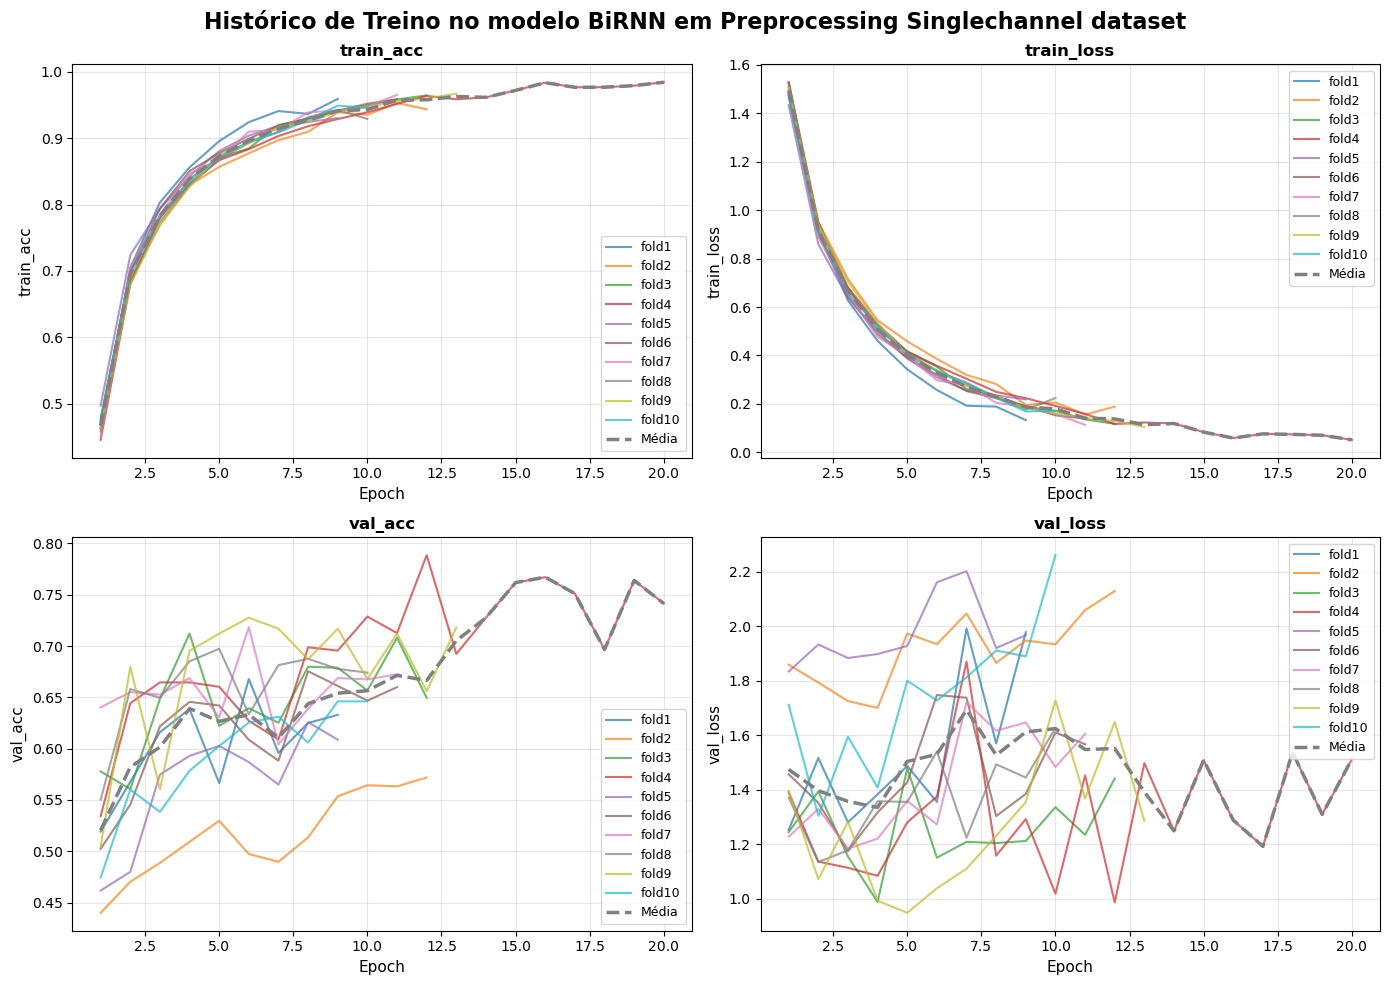

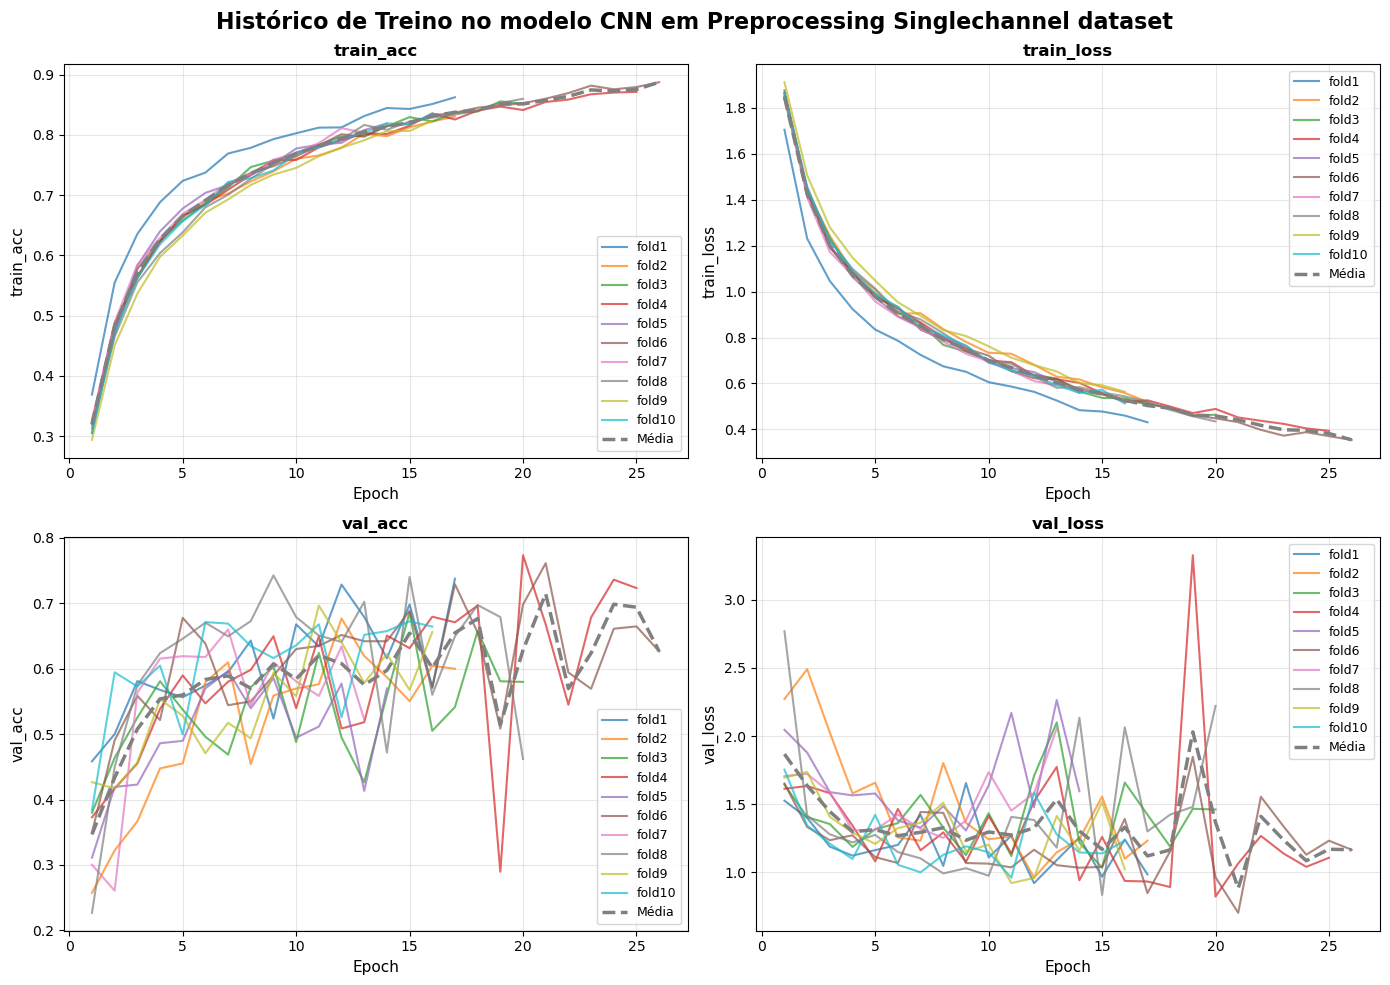

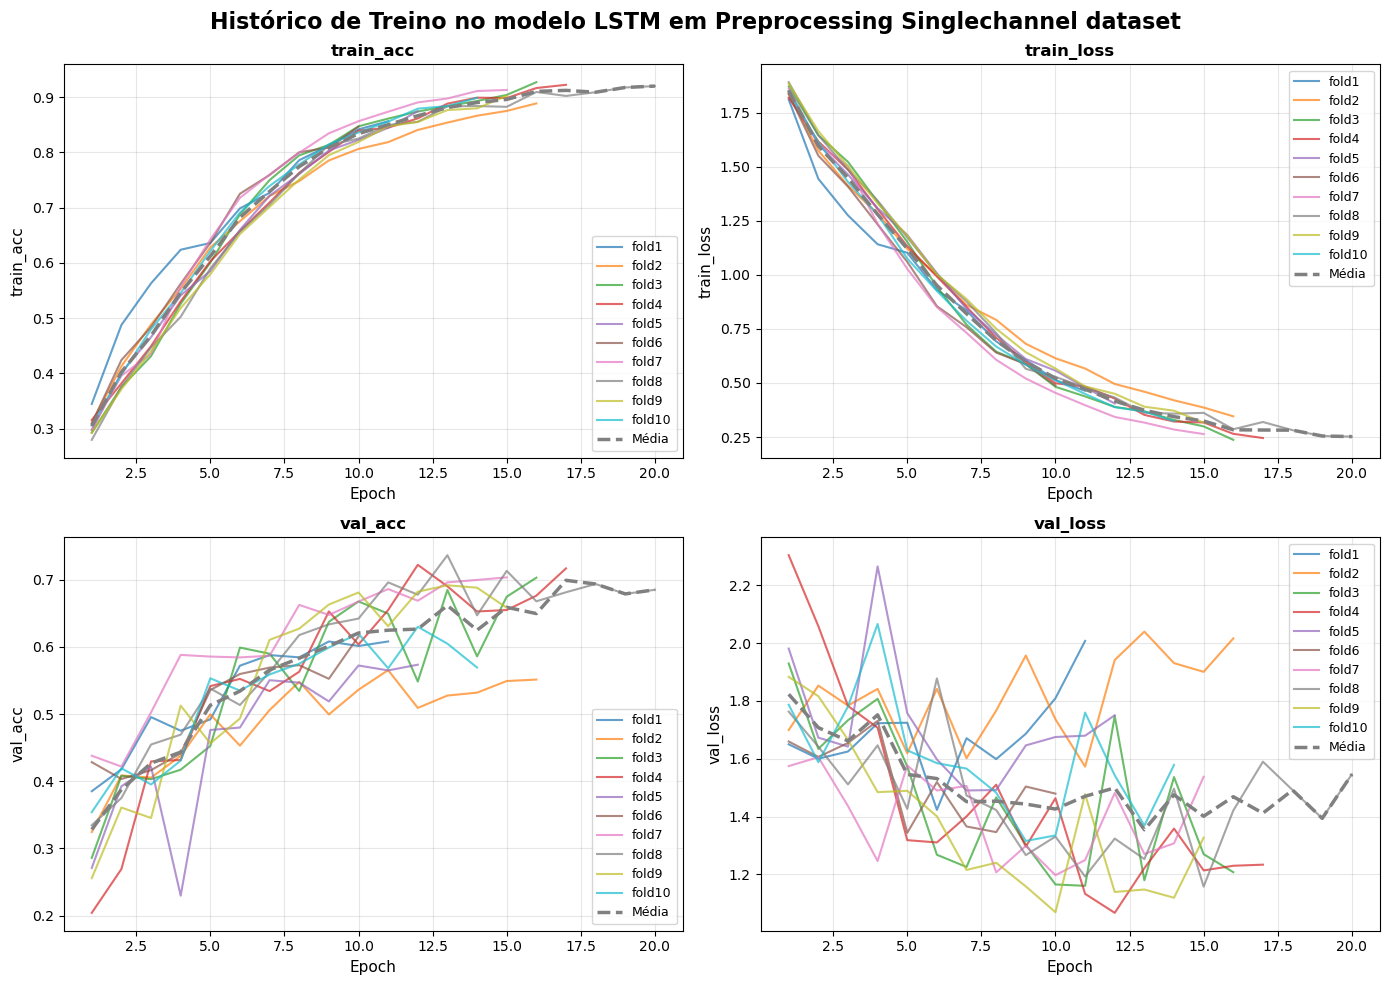

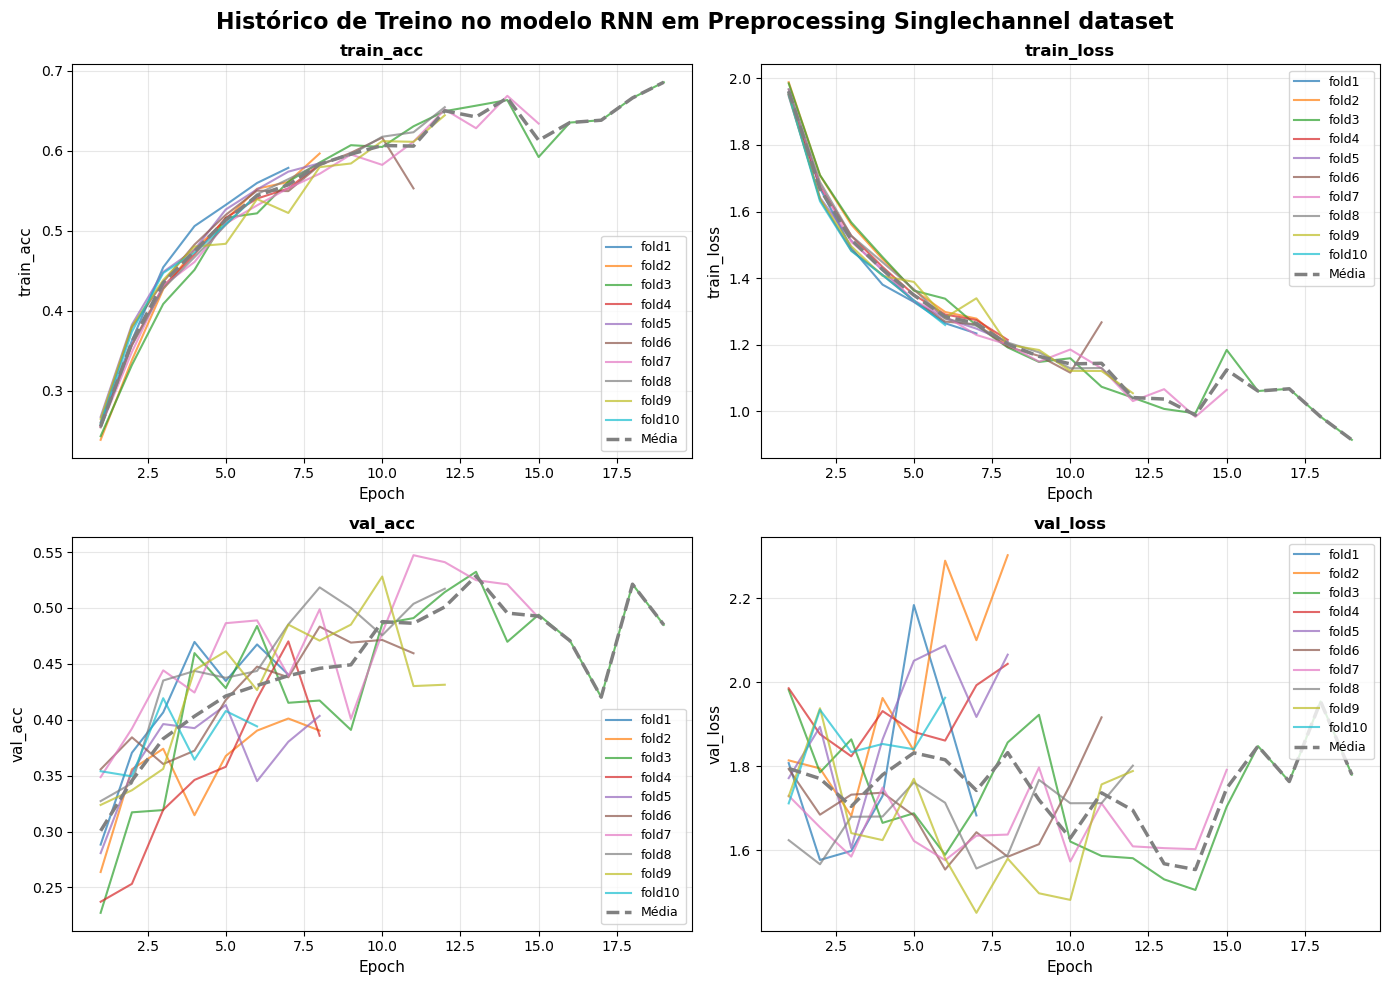

C:\Users\migue\AppData\Local\Temp\ipykernel_14248\4129859094.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)\


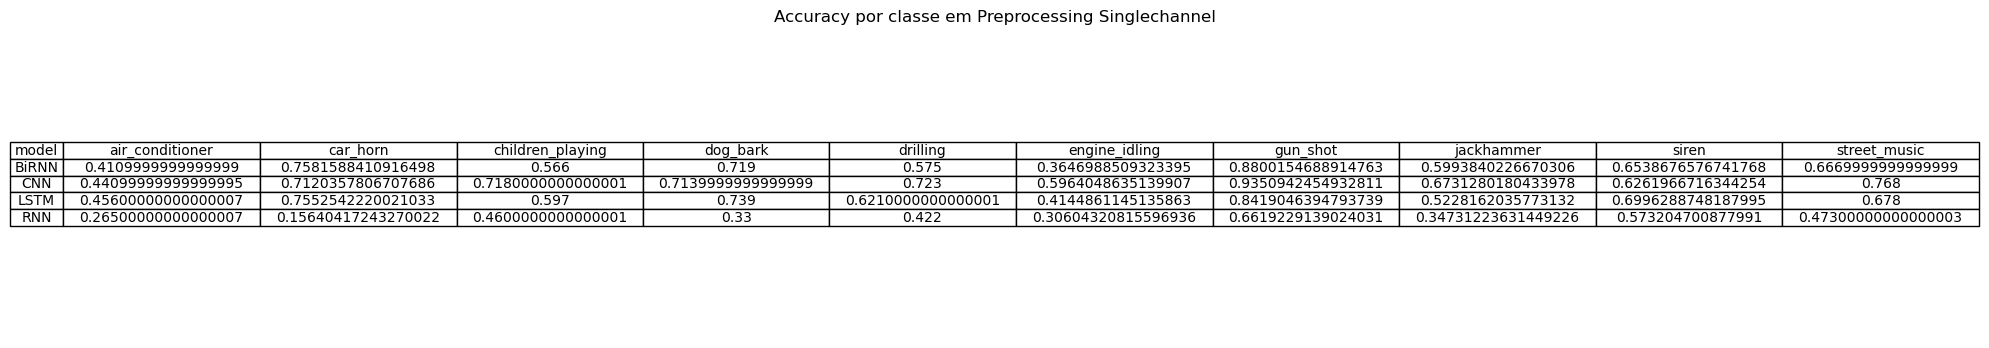

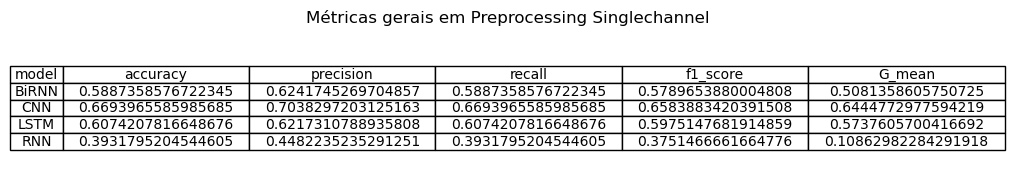

C:\Users\migue\AppData\Local\Temp\ipykernel_14248\2189741502.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)


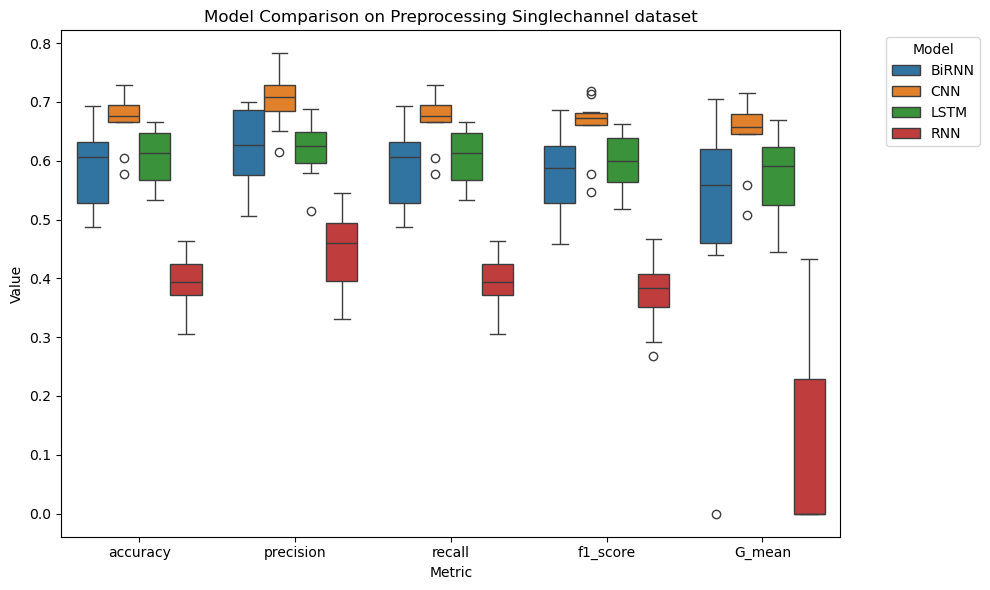

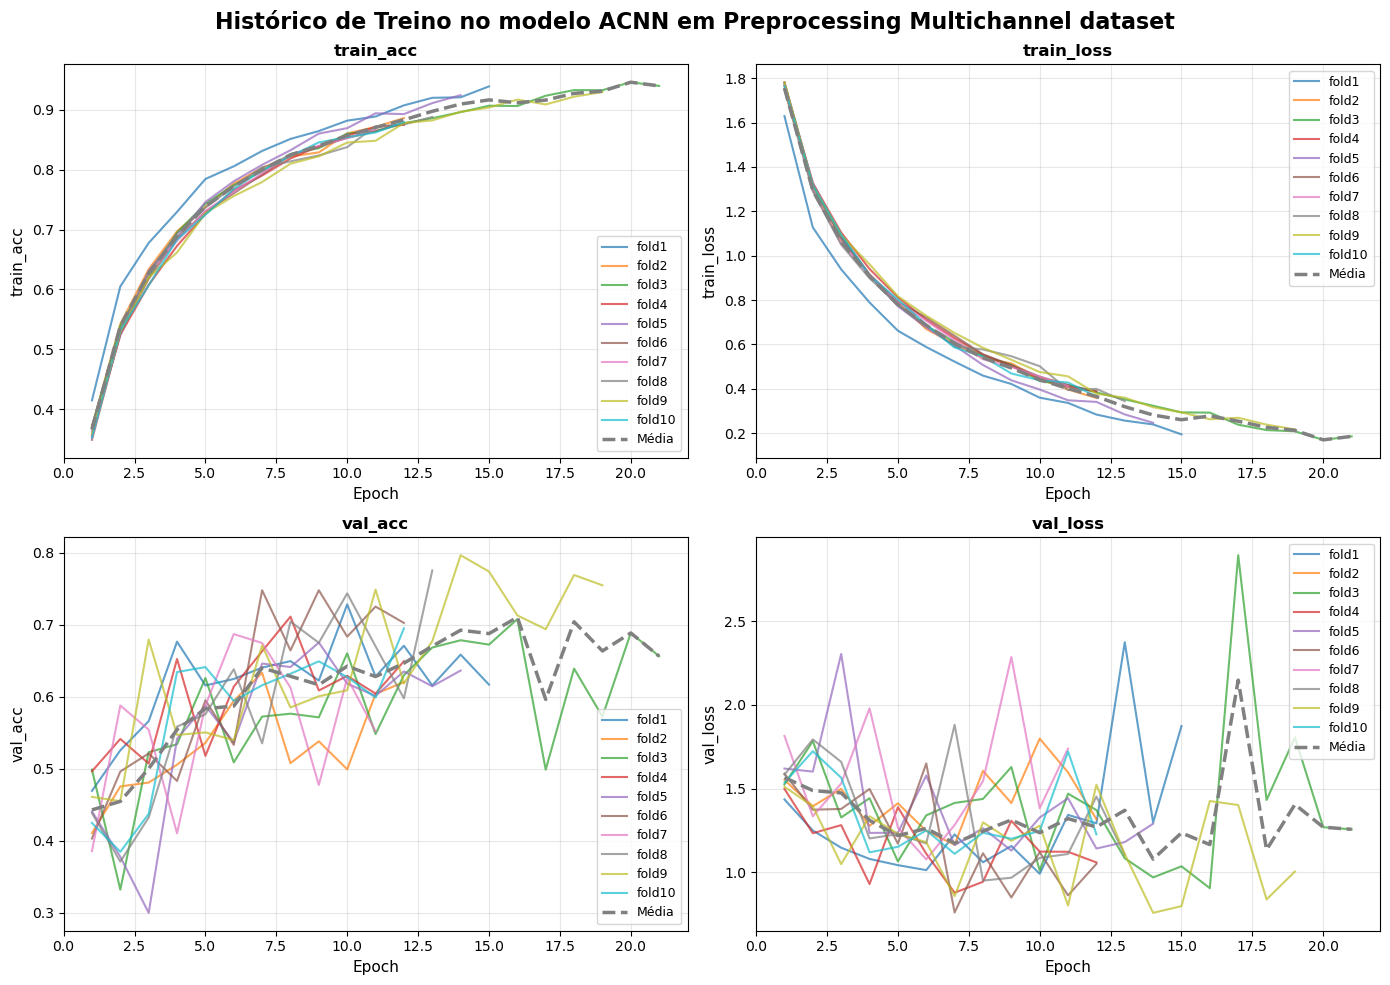

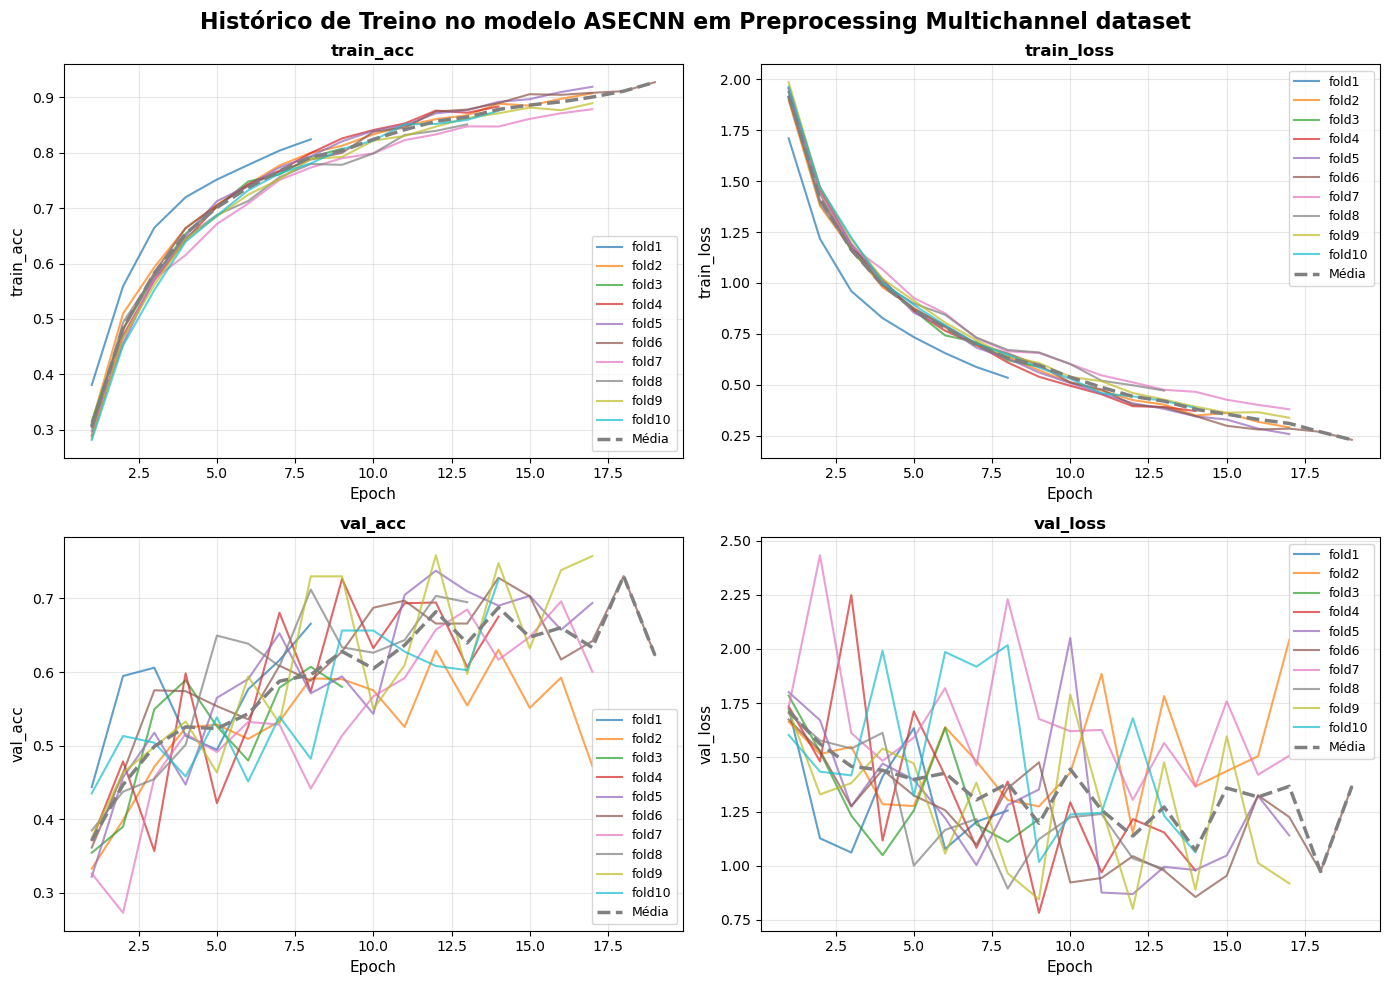

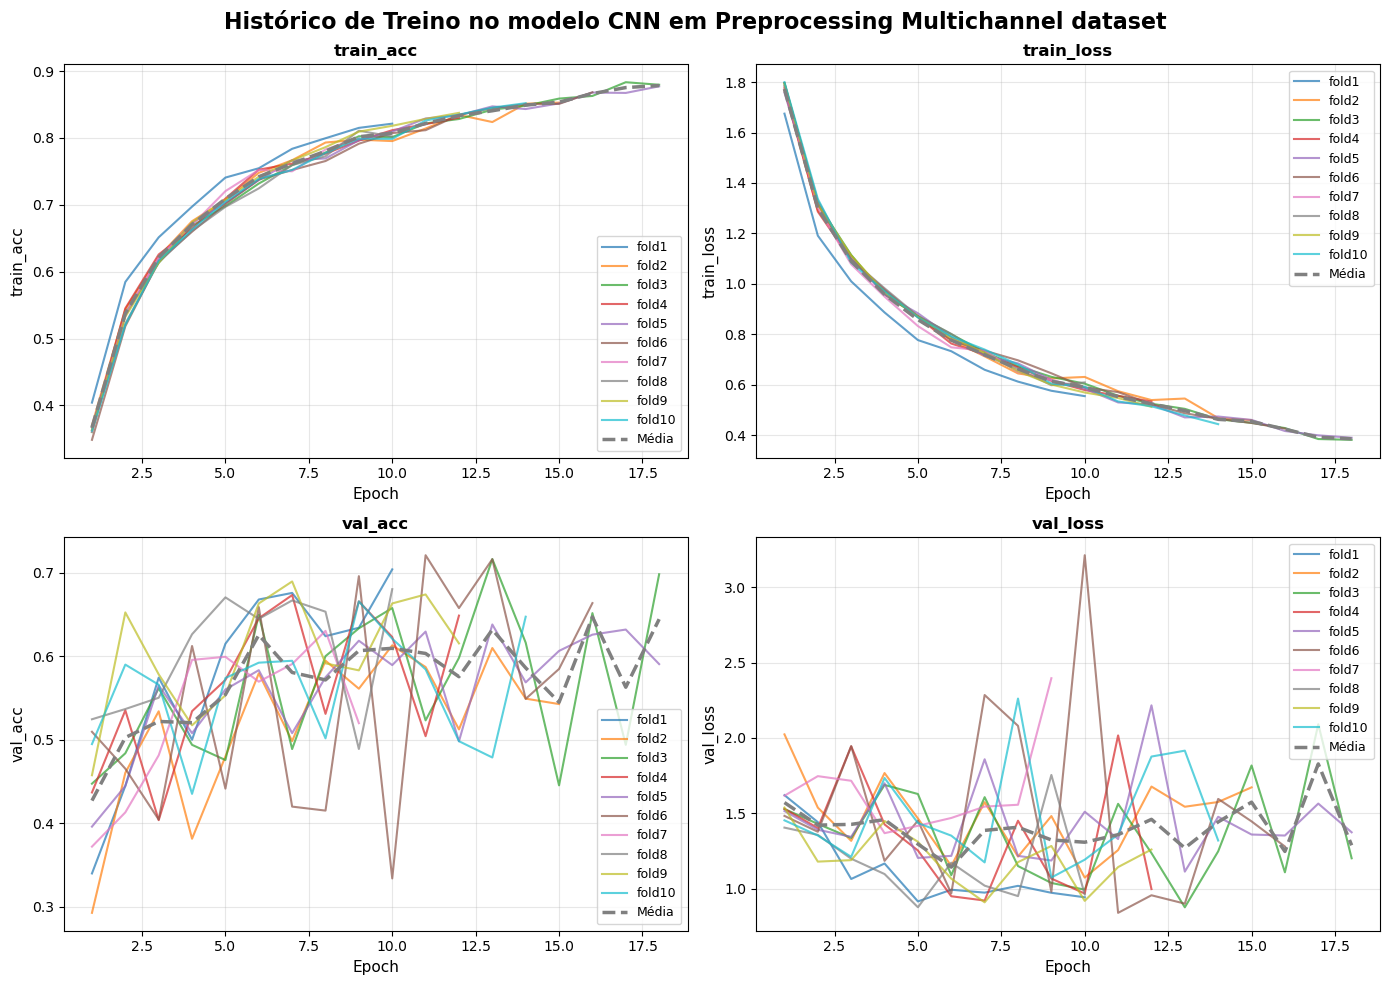

C:\Users\migue\AppData\Local\Temp\ipykernel_14248\4129859094.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)\


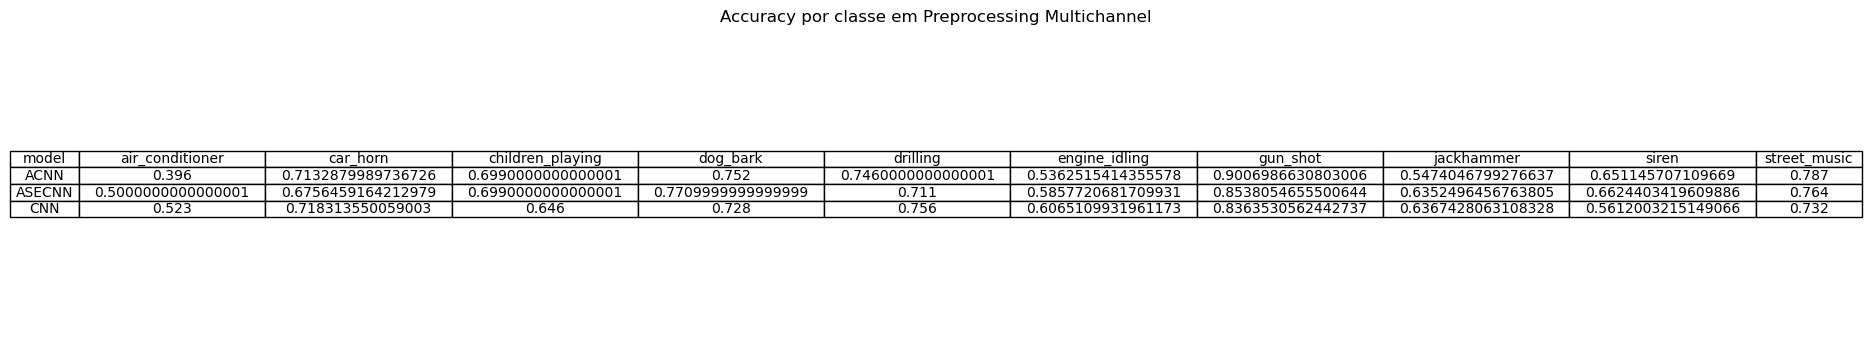

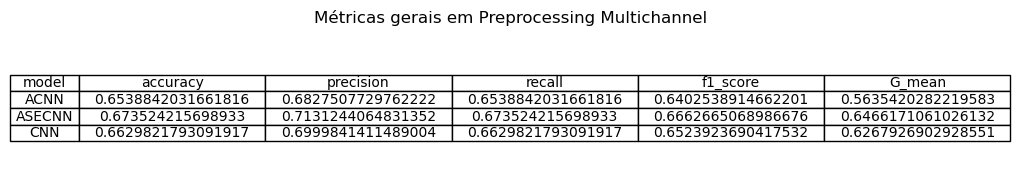

C:\Users\migue\AppData\Local\Temp\ipykernel_14248\2189741502.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)


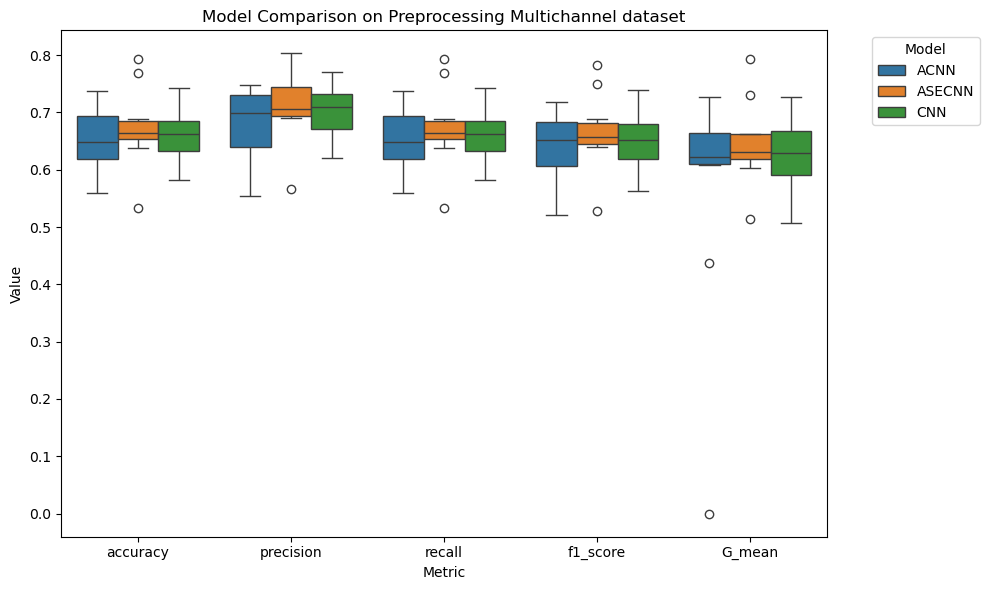

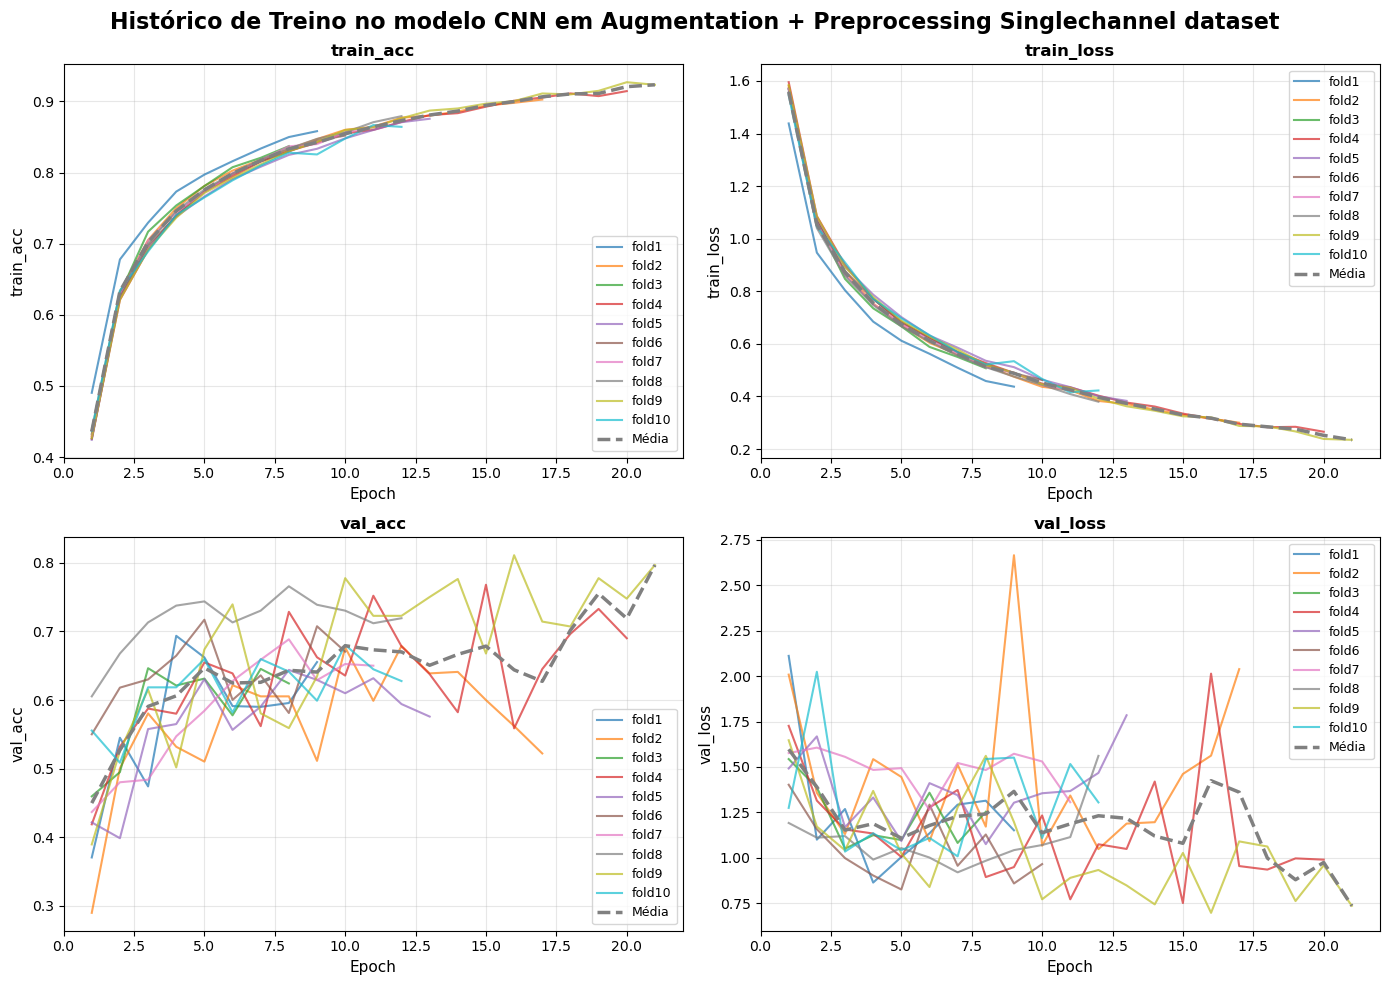

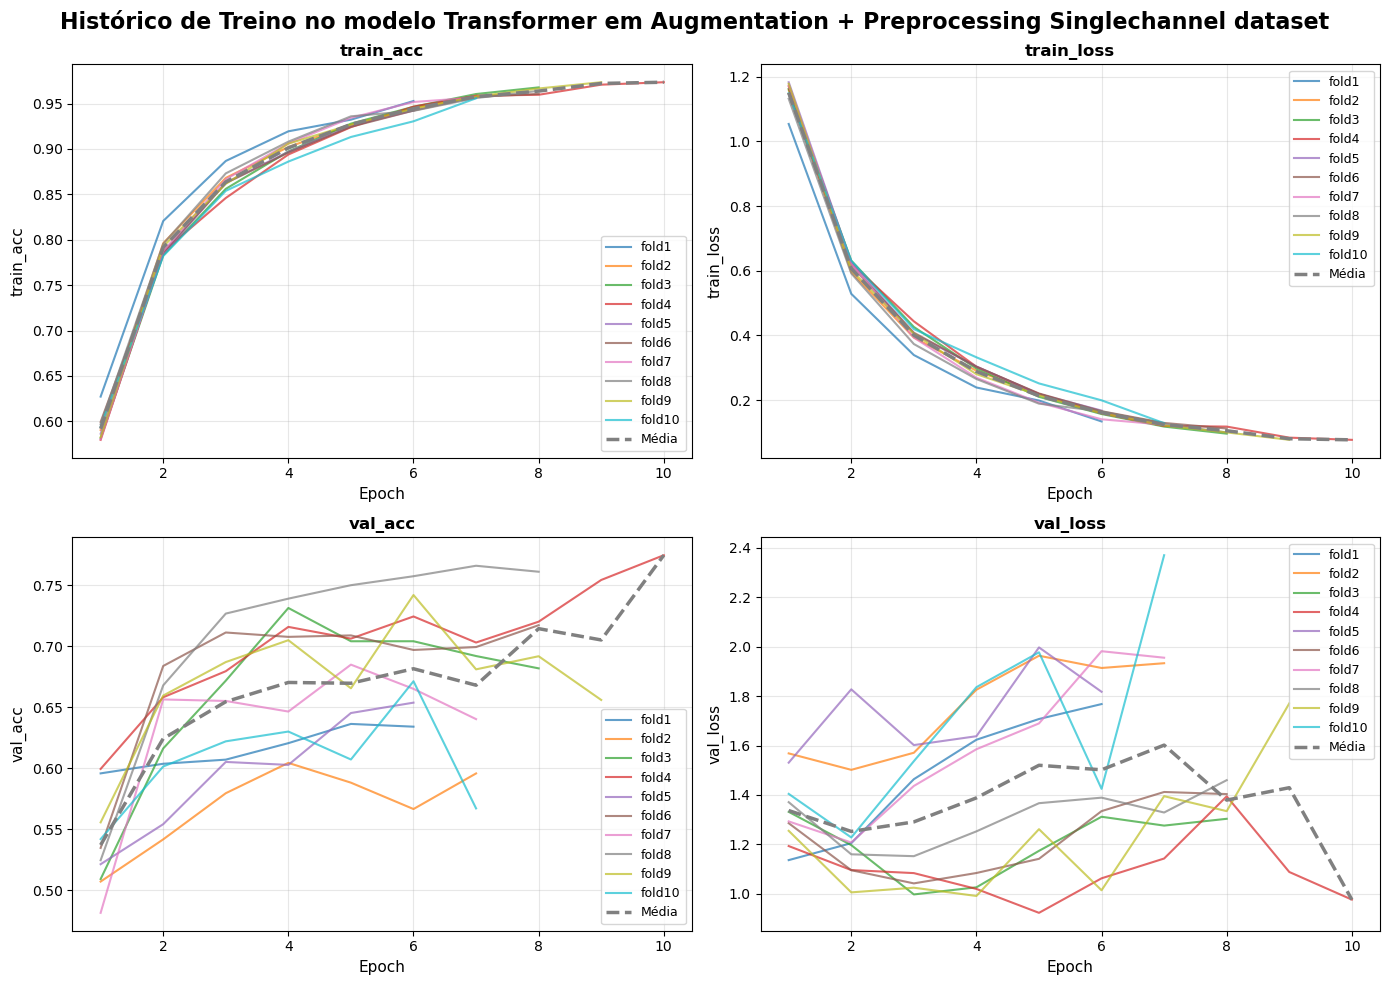

C:\Users\migue\AppData\Local\Temp\ipykernel_14248\4129859094.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)\


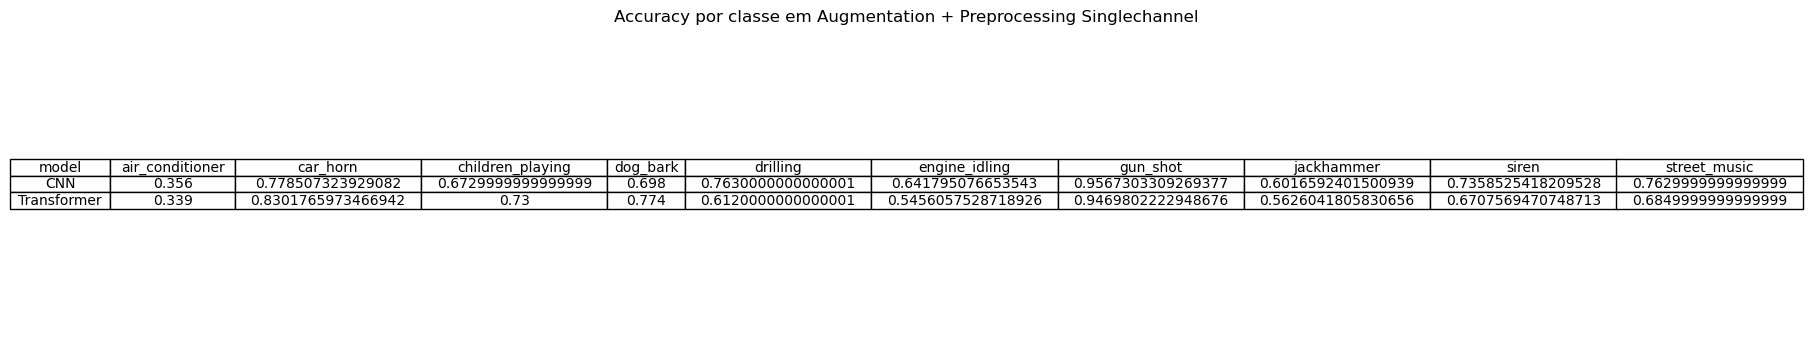

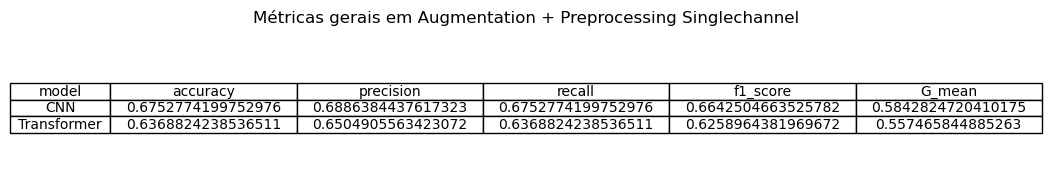

C:\Users\migue\AppData\Local\Temp\ipykernel_14248\2189741502.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)


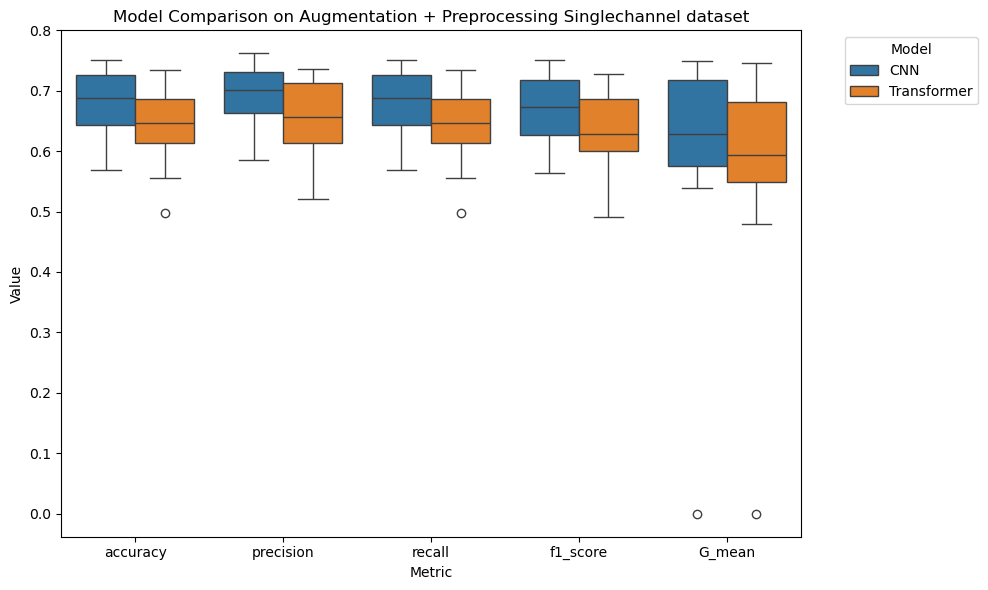

In [12]:
type = ["history", "metrics"]
datasets = ["singlechannel", "preprocessing", "augmentation_singlechannel"]
for dataset in datasets:
    for t in type:
        get_models_performance_dataset(path=os.path.join(os.getcwd(), "results"), dataset_name=dataset, type=t, plot=True)
    get_models_distributions_dataset(path=os.path.join(os.getcwd(), "results"), dataset_name=dataset, type="metrics", plot=True)

In [ ]:
# Comparação entre CNN e ASECNN usando os resultados de "metrics" do dataset "singlechannel"
results_path = os.path.join(os.getcwd(), "results")
dataset_name = "singlechannel"
type_metrics = "metrics"

# Obter o DataFrame de métricas
df_metrics = get_models_distributions_dataset(path=results_path, dataset_name=dataset_name, type=type_metrics, plot=False)

# Filtrar apenas CNN e ASECNN
df_compare = df_metrics[df_metrics['model'].isin(['CNN', 'ASECNN'])]

# Plotar comparação das métricas principais
plt.figure(figsize=(8, 5))
df_box = df_compare.melt(id_vars=["model"], value_vars=["accuracy", "precision", "recall", "f1_score", "G_mean"],
                         var_name="Métrica", value_name="Valor")
ax = sns.boxplot(x="Métrica", y="Valor", hue="model", data=df_box)
ax.set_title('Comparação CNN vs ASECNN no dataset Singlechannel')
plt.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()